In [ ]:
import pandas as pd

df = pd.read_csv('../data/indian_reddit_sentiment.csv')


['Noooooo take me back to the pink and purple it fucked so hard',
 'In Bajrangi Bhaijaan the major driving force come from the character of Munni (played by Harshaali Malhotra) her role is more emotionally impactful than Salman’s',
 'Michael neser is next in line after boland',
 "This will slightly raise the confidence of Pakistan heading into Sunday's game",
 "It's like being born on the finish line and claiming merit. \n\nWe should do what China did. Ban tuition centres and edtech. Free education for everyone."]

In [60]:
x=df.sample()['comments'].to_string()
x

'31812    Oh my god 😭\\nAnother one of my childhood memor...'

In [70]:
import re
def clean_text(text):
    pattern=r'\n|\t|\r|http\S+|[^\w\s]'
    cleaned_text = re.sub(pattern,'',text)
    cleaned_text = cleaned_text.strip().lower()
    return cleaned_text


In [71]:
df['clean_comment'] = df['comments'].apply(clean_text)
df['clean_comment'].sample(5).tolist()

['ive heard great things about the google pixel 9 but im curious why some people choose google over samsung phones ive been a loyal samsung user for 78 years and ive never had the chance to try a pixel in this price range what advantages does the pixel offer that samsung doesnt',
 'all they had to do was just hide it for user',
 'harshit ranas batting ability is a mirage everyone says it exists i just havent seen it',
 'so is the new constitution compatible with the new sports code or will it have to be written again before the next elections',
 'thanks for doing this']

In [98]:
import numpy as np
X = df['clean_comment']
y = df['comment_sentiment']


In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)


In [100]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(86519,) (21630,) (86519,) (21630,)


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [110]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train_vec,y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

              precision    recall  f1-score   support

    negative       0.84      0.67      0.74      5255
     neutral       0.82      0.93      0.87      6644
    positive       0.86      0.88      0.87      9731

    accuracy                           0.84     21630
   macro avg       0.84      0.83      0.83     21630
weighted avg       0.84      0.84      0.84     21630



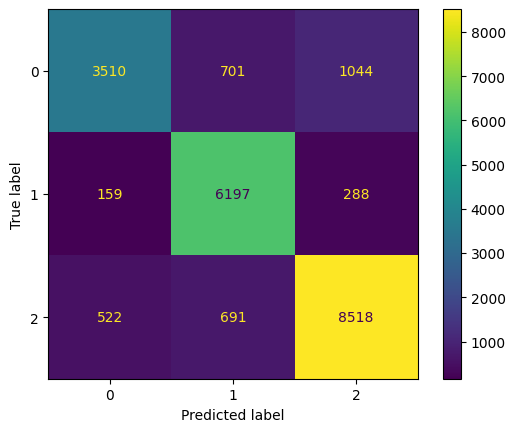

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
ypred= model.predict(X_test_vec)
print(classification_report(y_test,ypred))

cm = confusion_matrix(y_test,ypred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [121]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring='f1_weighted')
print(scores)
print(f"Mean: {scores.mean():.3f} (+/- {scores.std():.3f})")

[0.82872874 0.82584242 0.82248922 0.82300933 0.8236223 ]
Mean: 0.825 (+/- 0.002)


In [118]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.89      0.22      0.35      5255
     neutral       0.77      0.30      0.44      6644
    positive       0.53      0.96      0.68      9731

    accuracy                           0.58     21630
   macro avg       0.73      0.49      0.49     21630
weighted avg       0.69      0.58      0.52     21630



In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=4)
rf_model.fit(X_train_vec, y_train)

y_pred_rf = rf_model.predict(X_test_vec)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

    negative       0.89      0.33      0.48      5255
     neutral       0.74      0.82      0.78      6644
    positive       0.70      0.89      0.78      9731

    accuracy                           0.73     21630
   macro avg       0.78      0.68      0.68     21630
weighted avg       0.76      0.73      0.71     21630



In [122]:
import joblib

joblib.dump(model,'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']